<a href="https://colab.research.google.com/github/robertrichard86/Python/blob/main/Dataset_Iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto de Agrupamento: Dataset Iris
Nesta etapa inicial, realizamos a importação das bibliotecas essenciais para Ciência de Dados (`scikit-learn`, `pandas`, `seaborn`).

O dataset **Iris** é carregado e os dados passam por um processo de **Standardization** (Média 0 e Variância 1), garantindo que características com escalas diferentes (cm) não enviesem o cálculo de distância do K-Means.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Configuração estética dos gráficos
sns.set_theme(style="whitegrid")

# Carregando o dataset Iris
iris = load_iris()
X = iris.data
feature_names = iris.feature_names

# Escalonamento dos dados (Média 0, Variância 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Dataset carregado com {X.shape[0]} amostras e {X.shape[1]} características.")

Dataset carregado com 150 amostras e 4 características.


## 1. Método do Cotovelo (Elbow Method)
Para determinar o valor ideal de $k$, calculamos a **Inércia** (Soma dos Quadrados Intra-Cluster) para diferentes números de agrupamentos.

O objetivo é encontrar o ponto de "inflexão" no gráfico, onde adicionar mais clusters não resulta em uma melhora significativa na coesão dos dados. No caso do Iris, o ponto ideal visualizado é **$k=3$**.

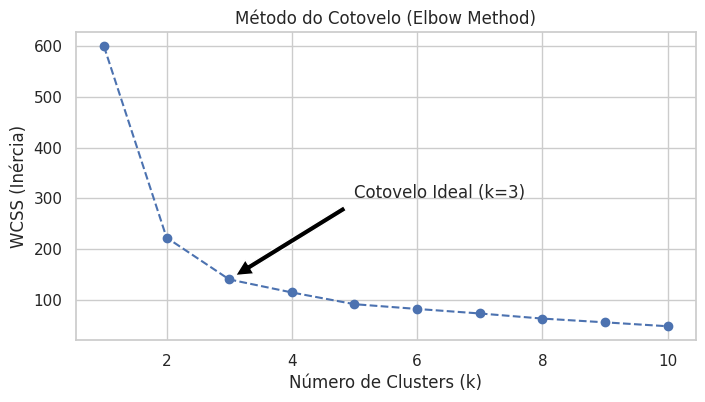

In [2]:
wcss = []
range_k = range(1, 11)

for i in range_k:
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range_k, wcss, marker='o', linestyle='--')
plt.title('Método do Cotovelo (Elbow Method)')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('WCSS (Inércia)')
plt.annotate('Cotovelo Ideal (k=3)', xy=(3, wcss[2]), xytext=(5, 300),
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.show()

## 2. Processamento e Redução de Dimensionalidade
Com o $k$ definido, aplicamos o algoritmo **K-Means**. Para visualizar dados de 4 dimensões em um plano 2D, utilizamos duas abordagens:

1. **PCA (Principal Component Analysis):** Uma técnica linear que transforma as variáveis originais em componentes que retêm a maior variância possível.
2. **t-SNE:** Uma técnica não-linear que mapeia pontos próximos no espaço multidimensional para pontos próximos no plano 2D, excelente para identificar estruturas locais.

In [3]:
# Aplicando K-Means com k=3
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Redução com PCA (Foco na variância global)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Redução com t-SNE (Foco na estrutura local/vizinhança)
# Perplexity costuma variar entre 5 e 50 dependendo do tamanho do dataset
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


## 3. Interpretação da Visualização Final
Ao comparar os gráficos, observamos que:
* O **PCA** demonstra uma separação clara da classe *Setosa*, mas mantém as classes *Versicolor* e *Virginica* próximas, refletindo a sobreposição real dessas espécies.
* O **t-SNE** tende a agrupar os pontos de forma mais compacta, criando "ilhas" de densidade, o que facilita a validação visual da coesão dos clusters gerados pelo K-Means.

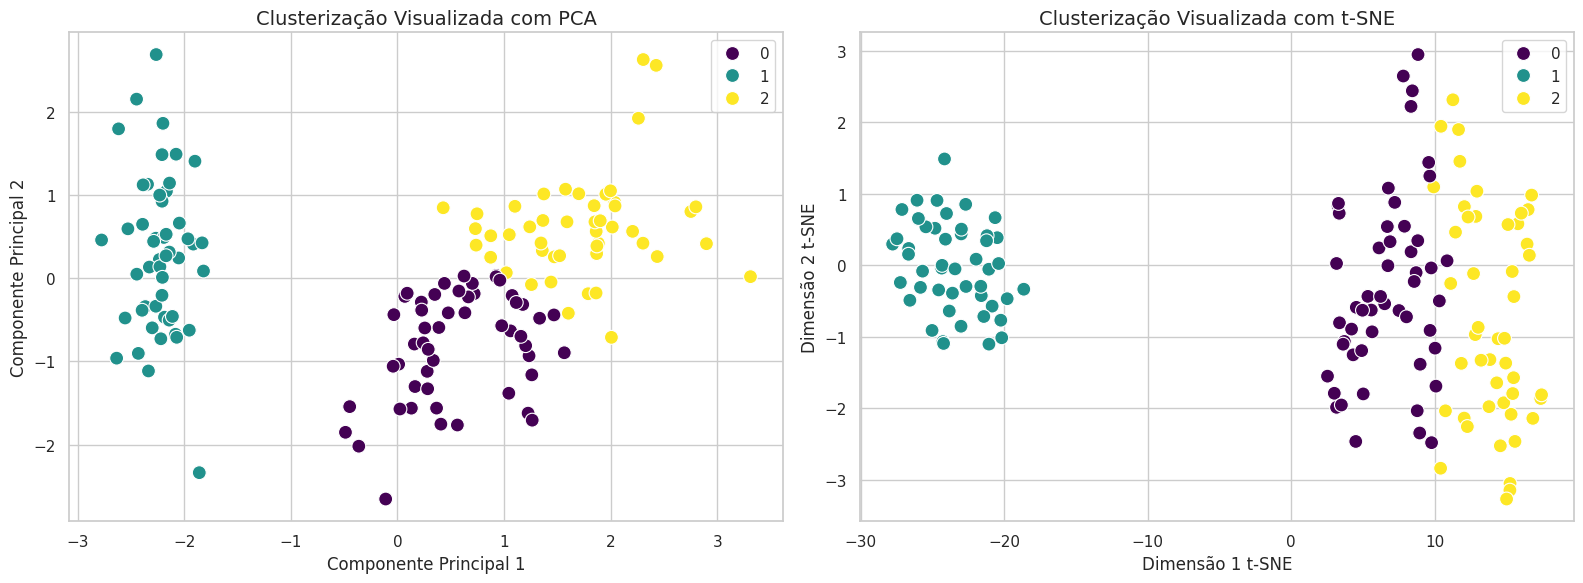

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot PCA
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters,
                palette='viridis', ax=ax1, s=100, edgecolor='w')
ax1.set_title('Clusterização Visualizada com PCA', fontsize=14)
ax1.set_xlabel('Componente Principal 1')
ax1.set_ylabel('Componente Principal 2')

# Plot t-SNE
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=clusters,
                palette='viridis', ax=ax2, s=100, edgecolor='w')
ax2.set_title('Clusterização Visualizada com t-SNE', fontsize=14)
ax2.set_xlabel('Dimensão 1 t-SNE')
ax2.set_ylabel('Dimensão 2 t-SNE')

plt.tight_layout()
plt.show()